In [4]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/smart-mcq-solver-challenge/sample_submission.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv


In [5]:
!pip -q install -U transformers datasets evaluate accelerate sentencepiece
!pip -q install -U wandb
!pip -q install -U scikit-learn
!pip -q install -U wordcloud

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 98.4 MB/s eta 0:00:00:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 33.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.2/389.2 kB 25.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 66.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 516.0/516.0 kB 28.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 104.0 MB/s eta 0:00:0000:010:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cu

In [6]:
from kaggle_secrets import UserSecretsClient
import wandb

user_secrets = UserSecretsClient()
api_key = user_secrets.get_secret("WANDB_API_KEY")

wandb.login(key=api_key)


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: 23f3002112 (23f3002112-indian-institute-of-technology-madras) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [7]:
# ==============================
# Standard Libraries
# ==============================
import os
import gc
import re
import math
import time
import random
import warnings
warnings.filterwarnings("ignore")

# ==============================
# Data Handling
# ==============================
import numpy as np
import pandas as pd

# ==============================
# Visualization
# ==============================
import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud

# ==============================
# Scikit-Learn
# ==============================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# ==============================
# PyTorch
# ==============================
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import (
    Dataset,
    DataLoader
)

# ==============================
# Hugging Face
# ==============================
from transformers import (
    AutoTokenizer,
    AutoModel,
    AutoModelForSequenceClassification,
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    get_linear_schedule_with_warmup
)

# ==============================
# W&B
# ==============================
import wandb

# ==============================
# Progress Bar
# ==============================
from tqdm.auto import tqdm

# ==============================
# Device
# ==============================
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("=" * 50)
print("PyTorch Version :", torch.__version__)
print("Device          :", DEVICE)
print("GPU Available   :", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU Name        :", torch.cuda.get_device_name(0))
print("=" * 50)



PyTorch Version : 2.10.0+cu128
Device          : cuda
GPU Available   : True
GPU Name        : Tesla T4


In [8]:
# ==========================================
# Random Seed for Reproducibility
# ==========================================

SEED = 42

import os
import random
import numpy as np
import torch

# Python
random.seed(SEED)

# Numpy
np.random.seed(SEED)

# Torch
torch.manual_seed(SEED)

# CUDA
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

# CuDNN
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Python Hash Seed
os.environ["PYTHONHASHSEED"] = str(SEED)

print("=" * 50)
print(f"Random Seed Fixed : {SEED}")
print("=" * 50)

Random Seed Fixed : 42


In [9]:
# ==========================================
# Load Dataset
# ==========================================

TRAIN_PATH = "/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv"
TEST_PATH = "/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv"
SUBMISSION_PATH = "/kaggle/input/competitions/smart-mcq-solver-challenge/sample_submission.csv"

train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)
sample_submission = pd.read_csv(SUBMISSION_PATH)

print("=" * 60)
print("Dataset Loaded Successfully")
print("=" * 60)

print(f"Train Shape              : {train_df.shape}")
print(f"Test Shape               : {test_df.shape}")
print(f"Submission Shape         : {sample_submission.shape}")

print("\nTrain Columns")
display(train_df.columns)

print("\nTest Columns")
display(test_df.columns)

print("\nSubmission Columns")
display(sample_submission.columns)

Dataset Loaded Successfully
Train Shape              : (2000, 8)
Test Shape               : (500, 7)
Submission Shape         : (500, 2)

Train Columns


Index(['id', 'prompt', 'A', 'B', 'C', 'D', 'E', 'answer'], dtype='object')


Test Columns


Index(['id', 'prompt', 'A', 'B', 'C', 'D', 'E'], dtype='object')


Submission Columns


Index(['ID', 'Prediction'], dtype='object')

Missing Values


id        0
prompt    0
A         0
B         0
C         0
D         0
E         0
answer    0
dtype: int64

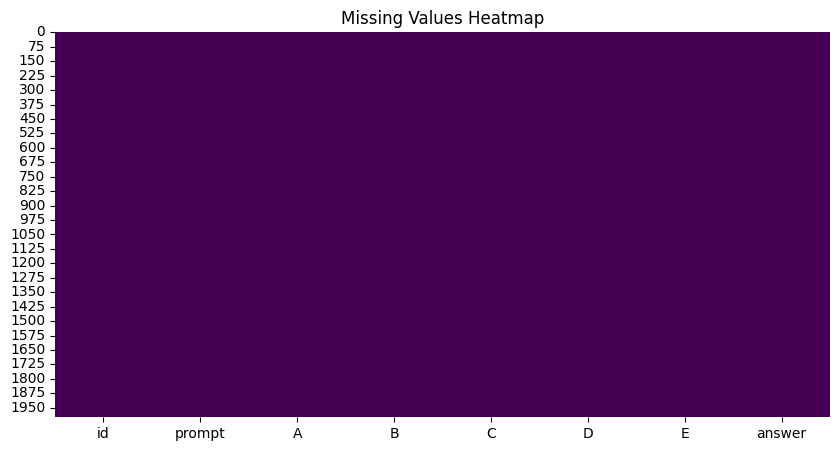

In [10]:
# ==========================================
# Missing Values Analysis
# ==========================================

print("=" * 50)
print("Missing Values")
print("=" * 50)

missing = train_df.isnull().sum()

display(missing)

plt.figure(figsize=(10,5))

sns.heatmap(
    train_df.isnull(),
    cbar=False,
    cmap="viridis"
)

plt.title("Missing Values Heatmap")
plt.show()

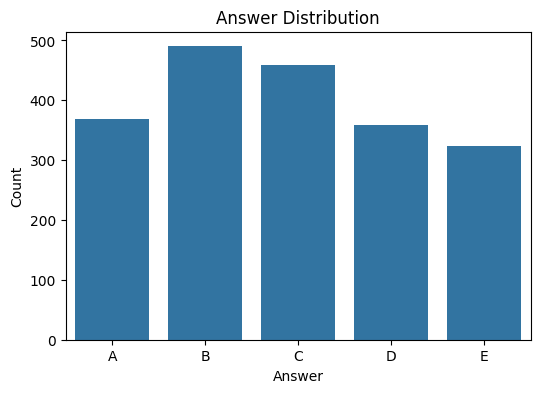


Percentage Distribution



answer
A    18.45
B    24.50
C    22.95
D    17.90
E    16.20
Name: proportion, dtype: float64

In [11]:
# ==========================================
# Answer Distribution
# ==========================================

plt.figure(figsize=(6,4))

sns.countplot(
    x=train_df["answer"],
    order=sorted(train_df["answer"].unique())
)

plt.title("Answer Distribution")
plt.xlabel("Answer")
plt.ylabel("Count")

plt.show()

print("\nPercentage Distribution\n")

display(
    (
        train_df["answer"]
        .value_counts(normalize=True)
        .sort_index()*100
    ).round(2)
)

,prompt_length,prompt_word_count
count,2000.000000,2000.00000
mean,117.669500,18.14650
std,44.408674,6.78189
min,19.000000,3.00000
25%,87.750000,14.00000
50%,111.000000,17.00000
75%,141.000000,22.00000
max,337.000000,51.00000


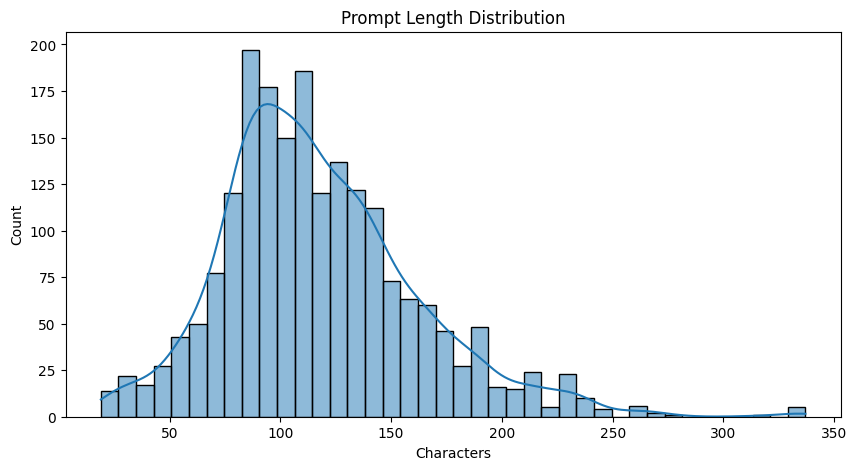

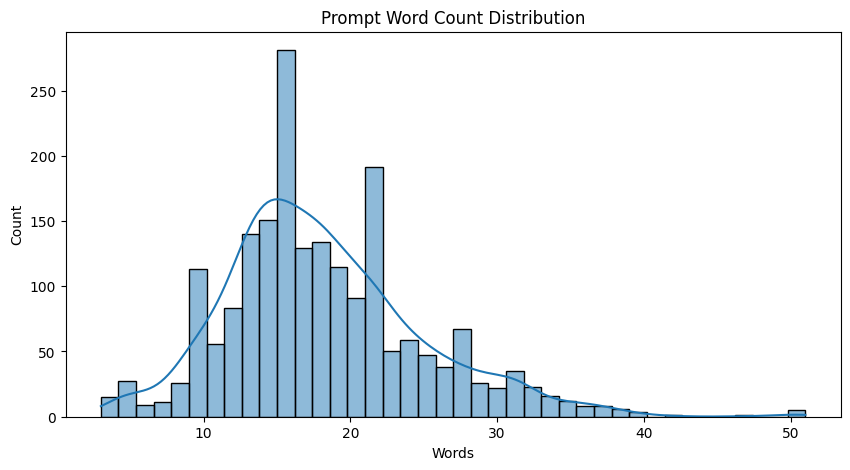

In [12]:
# ==========================================
# Prompt Length Analysis
# ==========================================

train_df["prompt_length"] = train_df["prompt"].astype(str).apply(len)

train_df["prompt_word_count"] = (
    train_df["prompt"]
    .astype(str)
    .apply(lambda x: len(x.split()))
)

display(
    train_df[
        ["prompt_length","prompt_word_count"]
    ].describe()
)

plt.figure(figsize=(10,5))

sns.histplot(
    train_df["prompt_length"],
    bins=40,
    kde=True
)

plt.title("Prompt Length Distribution")
plt.xlabel("Characters")
plt.show()

plt.figure(figsize=(10,5))

sns.histplot(
    train_df["prompt_word_count"],
    bins=40,
    kde=True
)

plt.title("Prompt Word Count Distribution")
plt.xlabel("Words")
plt.show()

,A,B,C,D,E
count,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000
mean,164.091500,166.616500,167.227000,162.56350,164.230000
std,105.677145,113.829917,105.723674,104.11657,107.777712
min,1.000000,2.000000,2.000000,1.00000,2.000000
25%,86.000000,82.000000,88.000000,91.00000,84.000000
50%,143.000000,151.000000,158.000000,141.00000,144.000000
75%,234.000000,222.000000,224.000000,231.00000,224.000000
max,472.000000,662.000000,530.000000,450.00000,587.000000


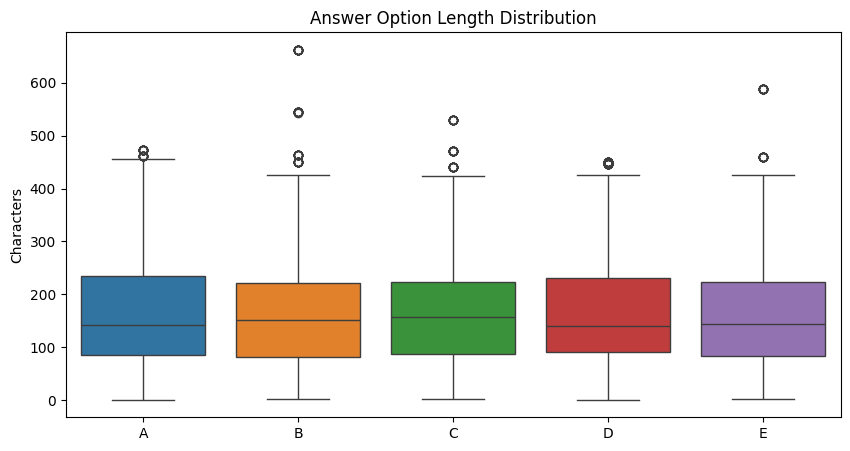

In [13]:
# ==========================================
# Option Length Analysis
# ==========================================

options = ["A","B","C","D","E"]

lengths = []

for col in options:
    lengths.append(
        train_df[col].astype(str).apply(len)
    )

option_df = pd.DataFrame(
    {
        "A": lengths[0],
        "B": lengths[1],
        "C": lengths[2],
        "D": lengths[3],
        "E": lengths[4]
    }
)

display(option_df.describe())

plt.figure(figsize=(10,5))

sns.boxplot(data=option_df)

plt.title("Answer Option Length Distribution")

plt.ylabel("Characters")

plt.show()

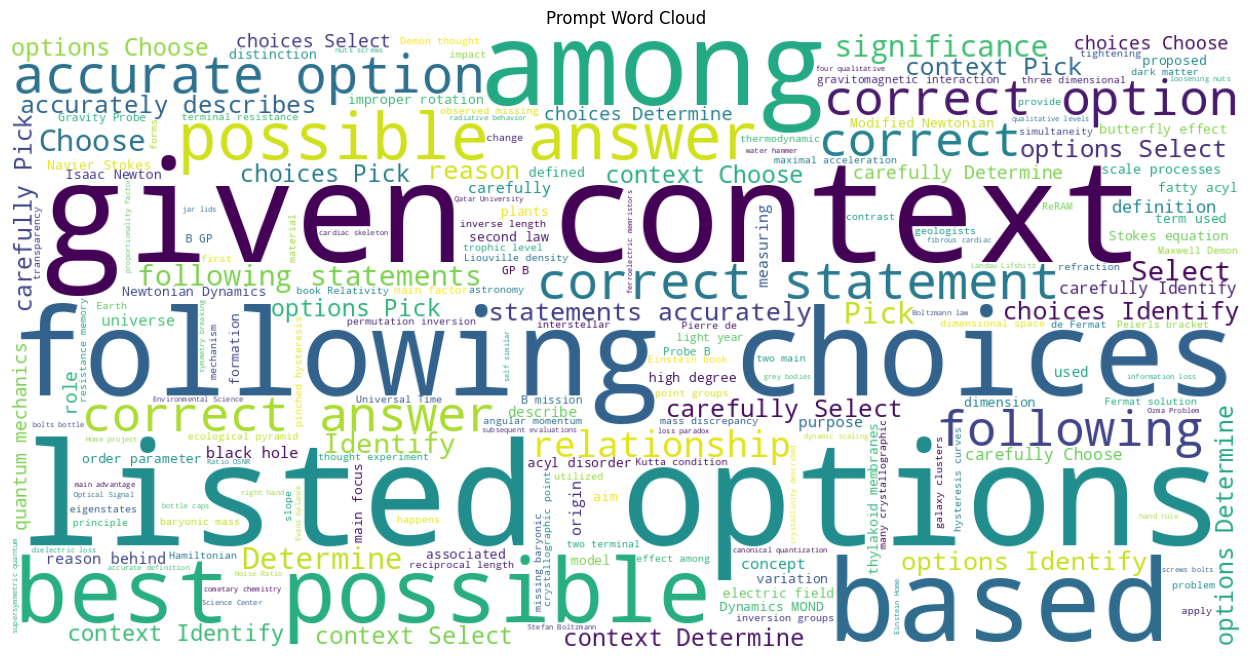

In [14]:
# ==========================================
# Prompt Word Cloud
# ==========================================

text = " ".join(
    train_df["prompt"].astype(str)
)

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    max_words=200
).generate(text)

plt.figure(figsize=(16,8))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Prompt Word Cloud")

plt.show()

,Word,Frequency
0,the,5528
1,is,1986
2,what,1809
3,of,1514
4,correct,893
5,following,746
6,in,714
7,answer:,608
8,option:,608
9,and,448


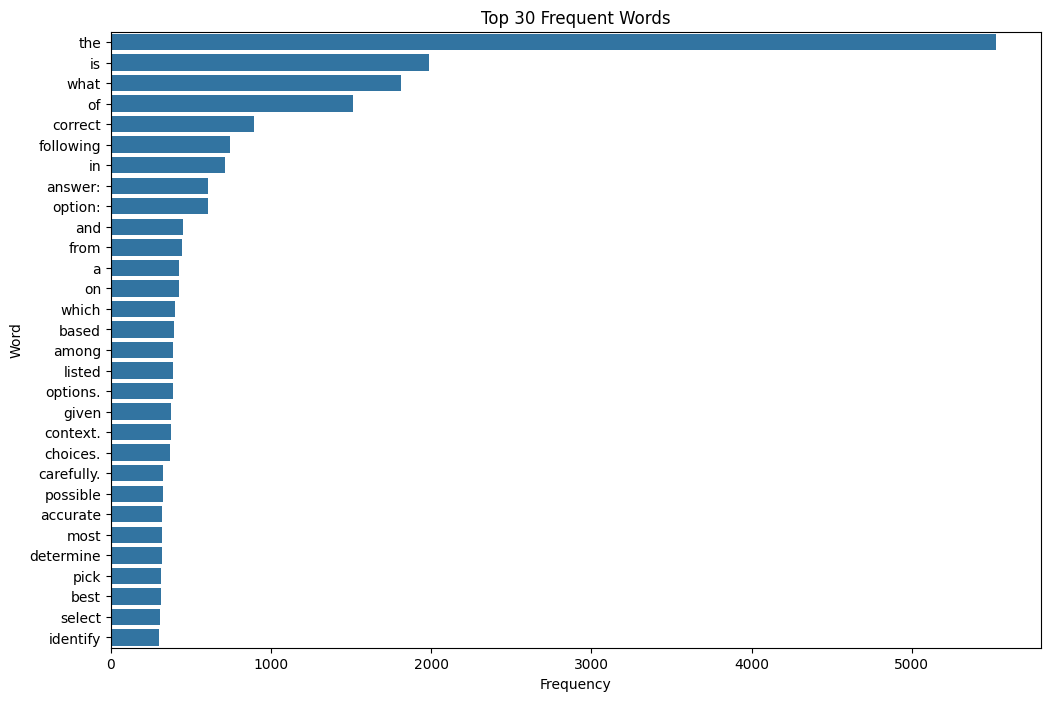

In [15]:
# ==========================================
# Top 30 Frequent Words
# ==========================================

from collections import Counter

words = []

for sentence in train_df["prompt"].astype(str):

    words.extend(sentence.lower().split())

counter = Counter(words)

top_words = counter.most_common(30)

freq_df = pd.DataFrame(
    top_words,
    columns=["Word","Frequency"]
)

display(freq_df)

plt.figure(figsize=(12,8))

sns.barplot(
    data=freq_df,
    x="Frequency",
    y="Word"
)

plt.title("Top 30 Frequent Words")

plt.show()

In [16]:
# ==========================================
# Basic Text Cleaning
# ==========================================

text_columns = ["prompt", "A", "B", "C", "D", "E"]

for col in text_columns:
    train_df[col] = (
        train_df[col]
        .fillna("")
        .astype(str)
        .str.lower()
        .str.strip()
    )

    test_df[col] = (
        test_df[col]
        .fillna("")
        .astype(str)
        .str.lower()
        .str.strip()
    )

print("Basic cleaning completed.")

display(train_df.head())

Basic cleaning completed.


,id,prompt,A,B,C,D,E,answer,prompt_length,prompt_word_count
0,1,pick the best possible answer: what is martin ...,martin heidegger believes that humans exist wi...,martin heidegger believes that humans do not e...,martin heidegger does not believe in the exist...,martin heidegger believes that the relationshi...,martin heidegger believes that time is an illu...,B,142,22
1,2,what is accelerator-based light-ion fusion?,accelerator-based light-ion fusion is a techni...,accelerator-based light-ion fusion is a techni...,accelerator-based light-ion fusion is a techni...,accelerator-based light-ion fusion is a techni...,accelerator-based light-ion fusion is a techni...,A,43,5
2,3,determine the correct option: what is the term...,blueshifting,redshifting,reddening,whitening,yellowing,C,182,27
3,4,select the most accurate option: what is marti...,martin heidegger believes that humans exist wi...,martin heidegger believes that humans do not e...,martin heidegger does not believe in the exist...,martin heidegger believes that the relationshi...,martin heidegger believes that time is an illu...,B,129,19
4,5,identify the correct statement: what is the co...,"simultaneity is relative, meaning that two eve...","simultaneity is relative, meaning that two eve...","simultaneity is absolute, meaning that two eve...",simultaneity is a concept that applies only to...,simultaneity is a concept that applies only to...,A,110,15


In [17]:
# ==========================================
# Advanced Cleaning
# ==========================================

def clean_text(text):

    text = str(text)

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", "", text)

    # Remove HTML tags
    text = re.sub(r"<.*?>", "", text)

    # Remove punctuation
    text = re.sub(r"[^\w\s]", " ", text)

    # Remove digits
    text = re.sub(r"\d+", " ", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text)

    return text.strip()


for col in text_columns:

    train_df[col] = train_df[col].apply(clean_text)
    test_df[col] = test_df[col].apply(clean_text)

print("Advanced cleaning completed.")

display(train_df.head())

Advanced cleaning completed.


,id,prompt,A,B,C,D,E,answer,prompt_length,prompt_word_count
0,1,pick the best possible answer what is martin h...,martin heidegger believes that humans exist wi...,martin heidegger believes that humans do not e...,martin heidegger does not believe in the exist...,martin heidegger believes that the relationshi...,martin heidegger believes that time is an illu...,B,142,22
1,2,what is accelerator based light ion fusion,accelerator based light ion fusion is a techni...,accelerator based light ion fusion is a techni...,accelerator based light ion fusion is a techni...,accelerator based light ion fusion is a techni...,accelerator based light ion fusion is a techni...,A,43,5
2,3,determine the correct option what is the term ...,blueshifting,redshifting,reddening,whitening,yellowing,C,182,27
3,4,select the most accurate option what is martin...,martin heidegger believes that humans exist wi...,martin heidegger believes that humans do not e...,martin heidegger does not believe in the exist...,martin heidegger believes that the relationshi...,martin heidegger believes that time is an illu...,B,129,19
4,5,identify the correct statement what is the con...,simultaneity is relative meaning that two even...,simultaneity is relative meaning that two even...,simultaneity is absolute meaning that two even...,simultaneity is a concept that applies only to...,simultaneity is a concept that applies only to...,A,110,15


In [18]:
# ==========================================
# Build Input Text
# ==========================================

def create_input_text(df):

    return (
        "Question: " + df["prompt"] +
        " [SEP] Option A: " + df["A"] +
        " [SEP] Option B: " + df["B"] +
        " [SEP] Option C: " + df["C"] +
        " [SEP] Option D: " + df["D"] +
        " [SEP] Option E: " + df["E"]
    )


train_df["input_text"] = create_input_text(train_df)
test_df["input_text"] = create_input_text(test_df)

print("Input text created.")

display(
    train_df[
        ["input_text","answer"]
    ].head()
)

Input text created.


,input_text,answer
0,Question: pick the best possible answer what i...,B
1,Question: what is accelerator based light ion ...,A
2,Question: determine the correct option what is...,C
3,Question: select the most accurate option what...,B
4,Question: identify the correct statement what ...,A


In [19]:
# ==========================================
# Label Encoding
# ==========================================

label_encoder = LabelEncoder()

train_df["label"] = label_encoder.fit_transform(
    train_df["answer"]
)

print("Classes :")

for i, cls in enumerate(label_encoder.classes_):
    print(f"{cls} -> {i}")

display(
    train_df[
        ["answer","label"]
    ].head()
)

Classes :
A -> 0
B -> 1
C -> 2
D -> 3
E -> 4


,answer,label
0,B,1
1,A,0
2,C,2
3,B,1
4,A,0


In [20]:
# ==========================================
# Train Validation Split
# ==========================================

train_texts, valid_texts, train_labels, valid_labels = train_test_split(
    train_df["input_text"],
    train_df["label"],
    test_size=0.20,
    random_state=SEED,
    stratify=train_df["label"],
    shuffle=True
)

print("="*50)

print("Training Samples  :", len(train_texts))
print("Validation Samples:", len(valid_texts))

print("="*50)

Training Samples  : 1600
Validation Samples: 400


In [21]:
MAX_LEN = 256
BATCH_SIZE = 16
EPOCHS = 15
LEARNING_RATE = 1e-3
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {DEVICE}")

# Tokenizer
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
vocab_size = tokenizer.vocab_size

print("=" * 60)
print("Hyperparameters & Tokenizer Loaded")

Using device: cuda


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Hyperparameters & Tokenizer Loaded


In [22]:
class MCQDataset(Dataset):
    def __init__(self, df, tokenizer, max_len, is_test=False):
        self.df = df
        self.tokenizer = tokenizer
        self.max_len = max_len
        self.is_test = is_test
        self.options = ['A', 'B', 'C', 'D', 'E']
        self.label_map = {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        prompt = str(row['prompt'])
        
        input_ids_list = []
        
        for opt in self.options:
            option_text = str(row[opt])
            combined_text = prompt + " [SEP] " + option_text
            
            encoded = self.tokenizer(combined_text,padding='max_length', truncation=True, max_length=self.max_len, return_tensors='pt')
            input_ids_list.append(encoded['input_ids'].squeeze(0))
            
        input_ids_tensor = torch.stack(input_ids_list)
        item = {'input_ids': input_ids_tensor}
        
        if not self.is_test:
            item['label'] = torch.tensor(self.label_map[row['answer']], dtype=torch.long)
            
        return item

print("=" * 60)
print(" MCQDataset Class Created")

 MCQDataset Class Created


In [23]:
class CustomTextCNN(nn.Module):
    def __init__(self, vocab_size, embed_dim=140, num_filters=100, filter_sizes=[3, 4, 5], num_classes=1):
        super(CustomTextCNN, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        
        self.convs = nn.ModuleList([
            nn.Conv1d(in_channels=embed_dim, out_channels=num_filters, kernel_size=k)
            for k in filter_sizes
        ])
        
        self.dropout = nn.Dropout(0.5)
        self.fc = nn.Linear(len(filter_sizes) * num_filters, num_classes)

    def forward(self, input_ids):
        batch_size, num_choices, seq_len = input_ids.shape
        x = input_ids.view(-1, seq_len)
        embedded = self.embedding(x).transpose(1, 2) 
        
        conv_results = []
        for conv in self.convs:
            c = torch.relu(conv(embedded))
            c = torch.max_pool1d(c, c.size(2)).squeeze(2)
            conv_results.append(c)
            
        out = torch.cat(conv_results, dim=1) 
        out = self.dropout(out)
        
        logits = self.fc(out)
        
        reshaped_logits = logits.view(batch_size, num_choices)
        return reshaped_logits

print("=" * 60)
print("CustomTextCNN Model Created")

CustomTextCNN Model Created


In [24]:
def mapk(actual, predicted, k=3):
    score = 0.0
    for a, p in zip(actual, predicted):
        p = p[:k]
        if a in p:
            score += 1.0 / (p.index(a) + 1)
    return score / len(actual)

print("=" * 60)
print("MAP@3 Evaluation Function Ready")

MAP@3 Evaluation Function Ready


In [25]:
def train_model():
    val_size = int(0.2 * len(train_df))
    train_data = train_df.iloc[:-val_size]
    val_data = train_df.iloc[-val_size:]
    
    train_dataset = MCQDataset(train_data, tokenizer, MAX_LEN)
    val_dataset = MCQDataset(val_data, tokenizer, MAX_LEN)
    
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
  
    model = CustomTextCNN(vocab_size=vocab_size).to(DEVICE)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)
    
    wandb.init(
        project="23f3002112-t22026", 
        name="Custom-CNN-Scratch",
        config={"architecture": "CNN", "epochs": EPOCHS, "batch_size": BATCH_SIZE, "lr": LEARNING_RATE}
    )
    wandb.watch(model, criterion, log="all", log_freq=10)
    
    for epoch in range(EPOCHS):
        model.train()
        total_loss = 0
        correct_preds = 0
        total_preds = 0
        
        for batch in train_loader:
            input_ids = batch['input_ids'].to(DEVICE)
            labels = batch['label'].to(DEVICE)
            
            optimizer.zero_grad()
            logits = model(input_ids)
            
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
            preds = torch.argmax(logits, dim=1)
            correct_preds += (preds == labels).sum().item()
            total_preds += labels.size(0)
            
        train_acc = correct_preds / total_preds
        train_loss = total_loss / len(train_loader)
        
        model.eval()
        val_loss = 0
        val_correct = 0
        val_total = 0
        actual_answers=[]
        predicted_answers=[]
        with torch.no_grad():
            for batch in val_loader:
                input_ids = batch['input_ids'].to(DEVICE)
                labels = batch['label'].to(DEVICE)
                
                logits = model(input_ids)
                loss = criterion(logits, labels)
                
                val_loss += loss.item()
                preds = torch.argmax(logits, dim=1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)
                top3 = torch.topk(logits, k=3,dim=1).indices.cpu().tolist()
                actual_answers.extend(labels.cpu().tolist())
                predicted_answers.extend(top3)
                
        val_acc = val_correct / val_total
        val_map3 = mapk(actual_answers,predicted_answers,k=3)
        avg_val_loss = val_loss / len(val_loader)
        
        print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.4f} | MAP@3:{val_map3:.4f}")
        
        # Log to WandB
        wandb.log({
            "Train Loss": train_loss, 
            "Train Accuracy": train_acc, 
            "Val Loss": avg_val_loss, 
            "Val Accuracy": val_acc,
            "Val MAP@3":val_map3,
            "Epoch": epoch + 1
        })
        
    torch.save(model.state_dict(), "cnn_mcq_model.pt")
    wandb.save("cnn_mcq_model.pt")
    
    return model, val_acc, val_map3


print("=" * 60)
print("Training Function Ready")


Training Function Ready


In [26]:
# Train & Evaluate Model 1

trained_model, model1_accuracy, model1_map3 = train_model()

print("\n" + "=" * 60)
print("MODEL 1 : CUSTOM TEXT CNN")
print("=" * 60)
print(f"Validation Accuracy : {model1_accuracy:.4f}")
print(f"Validation MAP@3    : {model1_map3:.4f}")
print("=" * 60)

wandb.finish()

Epoch 1/15 | Train Loss: 1.4150 | Train Acc: 0.4556 | Val Loss: 1.0235 | Val Acc: 0.9300 | MAP@3:0.9575
Epoch 2/15 | Train Loss: 0.9855 | Train Acc: 0.7119 | Val Loss: 0.7927 | Val Acc: 0.9625 | MAP@3:0.9738
Epoch 3/15 | Train Loss: 0.8351 | Train Acc: 0.7950 | Val Loss: 0.6827 | Val Acc: 0.9575 | MAP@3:0.9712
Epoch 4/15 | Train Loss: 0.7403 | Train Acc: 0.8500 | Val Loss: 0.6347 | Val Acc: 0.9700 | MAP@3:0.9783
Epoch 5/15 | Train Loss: 0.6998 | Train Acc: 0.8744 | Val Loss: 0.6004 | Val Acc: 0.9725 | MAP@3:0.9800
Epoch 6/15 | Train Loss: 0.6487 | Train Acc: 0.8981 | Val Loss: 0.5776 | Val Acc: 0.9725 | MAP@3:0.9796
Epoch 7/15 | Train Loss: 0.6377 | Train Acc: 0.9150 | Val Loss: 0.5736 | Val Acc: 0.9750 | MAP@3:0.9812
Epoch 8/15 | Train Loss: 0.6153 | Train Acc: 0.9225 | Val Loss: 0.5571 | Val Acc: 0.9725 | MAP@3:0.9800
Epoch 9/15 | Train Loss: 0.5969 | Train Acc: 0.9444 | Val Loss: 0.5481 | Val Acc: 0.9750 | MAP@3:0.9812
Epoch 10/15 | Train Loss: 0.5930 | Train Acc: 0.9381 | Val Loss:

wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.


Epoch 15/15 | Train Loss: 0.5605 | Train Acc: 0.9600 | Val Loss: 0.5461 | Val Acc: 0.9750 | MAP@3:0.9812

MODEL 1 : CUSTOM TEXT CNN
Validation Accuracy : 0.9750
Validation MAP@3    : 0.9812


Epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
Train Accuracy,▁▅▆▆▇▇▇▇███████
Train Loss,█▄▃▂▂▂▂▁▁▁▁▁▁▁▁
Val Accuracy,▁▆▅▇███████████
Val Loss,█▅▃▂▂▂▁▁▁▁▁▁▁▁▁
Val MAP@3,▁▆▅▇███████████
Epoch,15
Train Accuracy,0.96
Train Loss,0.56048
Val Accuracy,0.975
Val Loss,0.5461


In [29]:
# Model 2 : DistilBERT Configuration

MODEL_NAME = "distilbert-base-uncased"

MAX_LEN_BERT = 256
BATCH_SIZE_BERT = 16
EPOCHS_BERT = 3
LEARNING_RATE_BERT = 2e-5

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

bert_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print("=" * 60)
print("Model 2 : DistilBERT Configuration Loaded")
print(f"Model           : {MODEL_NAME}")
print(f"Device          : {DEVICE}")
print(f"Epochs          : {EPOCHS_BERT}")
print(f"Batch Size      : {BATCH_SIZE_BERT}")
print(f"Learning Rate   : {LEARNING_RATE_BERT}")
print("=" * 60)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Model 2 : DistilBERT Configuration Loaded
Model           : distilbert-base-uncased
Device          : cuda
Epochs          : 3
Batch Size      : 16
Learning Rate   : 2e-05


In [31]:
# DistilBERT Dataset

class DistilBERTDataset(Dataset):

    def __init__(self, dataframe, tokenizer, max_len):

        self.df = dataframe.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):

        text = self.df.loc[index, "input_text"]
        label = self.df.loc[index, "label"]

        encoding = self.tokenizer(
            text,
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt"
        )

        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "label": torch.tensor(label, dtype=torch.long)
        }

print("=" * 60)
print("DistilBERT Dataset Ready")

DistilBERT Dataset Ready


In [32]:
# DistilBERT Model

bert_model = DistilBertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=5
)

bert_model.to(DEVICE)

print("=" * 60)
print("DistilBERT Model Loaded Successfully")

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBERT Model Loaded Successfully


In [33]:
# ==========================================
# DistilBERT Training Function
# ==========================================

def train_bert_model():
    train_data = train_df.loc[train_texts.index].reset_index(drop=True)
    val_data = train_df.loc[valid_texts.index].reset_index(drop=True)

    train_dataset = DistilBERTDataset(train_data, bert_tokenizer, MAX_LEN_BERT)
    val_dataset = DistilBERTDataset(val_data, bert_tokenizer, MAX_LEN_BERT)

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE_BERT, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE_BERT, shuffle=False)

    optimizer = torch.optim.AdamW(bert_model.parameters(), lr=LEARNING_RATE_BERT, weight_decay=0.01)

    total_steps = len(train_loader) * EPOCHS_BERT
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=int(0.1 * total_steps),
        num_training_steps=total_steps
    )

    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

    wandb.init(
        project="23f3002112-t22026",
        name="DistilBERT-Finetune",
        config={
            "architecture": "DistilBERT",
            "epochs": EPOCHS_BERT,
            "batch_size": BATCH_SIZE_BERT,
            "lr": LEARNING_RATE_BERT
        }
    )
    wandb.watch(bert_model, criterion, log="all", log_freq=50)

    for epoch in range(EPOCHS_BERT):
        bert_model.train()
        total_loss = 0
        correct_preds = 0
        total_preds = 0

        loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS_BERT} [Train]")
        for batch in loop:
            input_ids = batch['input_ids'].to(DEVICE)
            attention_mask = batch['attention_mask'].to(DEVICE)
            labels = batch['label'].to(DEVICE)

            optimizer.zero_grad()
            outputs = bert_model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits

            loss = criterion(logits, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(bert_model.parameters(), max_norm=1.0)
            optimizer.step()
            scheduler.step()

            total_loss += loss.item()
            preds = torch.argmax(logits, dim=1)
            correct_preds += (preds == labels).sum().item()
            total_preds += labels.size(0)
            loop.set_postfix(loss=loss.item())

        train_acc = correct_preds / total_preds
        train_loss = total_loss / len(train_loader)

        bert_model.eval()
        val_loss = 0
        val_correct = 0
        val_total = 0
        actual_answers = []
        predicted_answers = []

        with torch.no_grad():
            for batch in val_loader:
                input_ids = batch['input_ids'].to(DEVICE)
                attention_mask = batch['attention_mask'].to(DEVICE)
                labels = batch['label'].to(DEVICE)

                outputs = bert_model(input_ids=input_ids, attention_mask=attention_mask)
                logits = outputs.logits
                loss = criterion(logits, labels)

                val_loss += loss.item()
                preds = torch.argmax(logits, dim=1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

                top3 = torch.topk(logits, k=3, dim=1).indices.cpu().tolist()
                actual_answers.extend(labels.cpu().tolist())
                predicted_answers.extend(top3)

        val_acc = val_correct / val_total
        val_map3 = mapk(actual_answers, predicted_answers, k=3)
        avg_val_loss = val_loss / len(val_loader)

        print(f"Epoch {epoch+1}/{EPOCHS_BERT} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.4f} | MAP@3: {val_map3:.4f}")

        wandb.log({
            "Train Loss": train_loss,
            "Train Accuracy": train_acc,
            "Val Loss": avg_val_loss,
            "Val Accuracy": val_acc,
            "Val MAP@3": val_map3,
            "Epoch": epoch + 1
        })

    torch.save(bert_model.state_dict(), "distilbert_mcq_model.pt")
    wandb.save("distilbert_mcq_model.pt")

    return bert_model, val_acc, val_map3


print("=" * 60)
print("DistilBERT Training Function Ready")


DistilBERT Training Function Ready


In [34]:
# Train & Evaluate Model 2 (DistilBERT)

trained_bert_model, model2_accuracy, model2_map3 = train_bert_model()

print("\n" + "=" * 60)
print("MODEL 2 : DISTILBERT")
print("=" * 60)
print(f"Validation Accuracy : {model2_accuracy:.4f}")
print(f"Validation MAP@3    : {model2_map3:.4f}")
print("=" * 60)

wandb.finish()

Epoch 1/3 [Train]:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch 1/3 | Train Loss: 1.4883 | Train Acc: 0.4094 | Val Loss: 1.1828 | Val Acc: 0.7225 | MAP@3: 0.8329


Epoch 2/3 [Train]:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch 2/3 | Train Loss: 0.8484 | Train Acc: 0.8962 | Val Loss: 0.5672 | Val Acc: 0.9775 | MAP@3: 0.9858


Epoch 3/3 [Train]:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch 3/3 | Train Loss: 0.4963 | Train Acc: 0.9938 | Val Loss: 0.4478 | Val Acc: 0.9925 | MAP@3: 0.9962


wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.



MODEL 2 : DISTILBERT
Validation Accuracy : 0.9925
Validation MAP@3    : 0.9962


Epoch,▁▅█
Train Accuracy,▁▇█
Train Loss,█▃▁
Val Accuracy,▁██
Val Loss,█▂▁
Val MAP@3,▁██
Epoch,3
Train Accuracy,0.99375
Train Loss,0.49633
Val Accuracy,0.9925
Val Loss,0.44783


In [35]:
# Model 3 : TF-IDF Feature Extraction

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    stop_words="english",
    lowercase=True
)

# Fit only on training data
X_train_tfidf = tfidf_vectorizer.fit_transform(train_texts)

# Transform validation and test data
X_valid_tfidf = tfidf_vectorizer.transform(valid_texts)
X_test_tfidf = tfidf_vectorizer.transform(test_df["input_text"])

print("=" * 60)
print("Model 3 : TF-IDF Vectorization Completed")
print("=" * 60)
print(f"Training Shape   : {X_train_tfidf.shape}")
print(f"Validation Shape : {X_valid_tfidf.shape}")
print(f"Test Shape       : {X_test_tfidf.shape}")
print(f"Vocabulary Size  : {len(tfidf_vectorizer.vocabulary_)}")
print("=" * 60)

Model 3 : TF-IDF Vectorization Completed
Training Shape   : (1600, 5000)
Validation Shape : (400, 5000)
Test Shape       : (500, 5000)
Vocabulary Size  : 5000


In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
import time
import numpy as np # Import numpy for argsort

# Initialize WandB for Logistic Regression
wandb.init(
    project="23f3002112-t22026",
    name="Logistic-Regression-TFIDF",
    config={
        "architecture": "Logistic Regression",
        "max_iter": 1000,
        "solver": "saga",
        "penalty": "l2"
    }
)

start_time_lr = time.time()

# Initialize and train Logistic Regression model
lr_model = LogisticRegression(
    max_iter=1000, # Increased iterations for convergence
    solver='saga', # Supports l2 penalty and multiclass
    penalty='l2',
    random_state=SEED,
    n_jobs=-1 # Use all available cores
)
lr_model.fit(X_train_tfidf, train_labels)

end_time_lr = time.time()
training_time_lr = end_time_lr - start_time_lr
print(f"Logistic Regression training completed in {training_time_lr:.2f} seconds.")

# Predict on validation set
valid_preds_lr = lr_model.predict(X_valid_tfidf)
valid_probs_lr = lr_model.predict_proba(X_valid_tfidf)

# Calculate metrics
model3_accuracy = accuracy_score(valid_labels, valid_preds_lr)
model3_f1 = f1_score(valid_labels, valid_preds_lr, average='weighted')

# Calculate MAP@3
actual_labels_lr = valid_labels.tolist()
predicted_probs_lr = valid_probs_lr

# Get top 3 predicted labels based on probabilities
predicted_top3_lr = np.argsort(predicted_probs_lr, axis=1)[:, -3:][:, ::-1]

# Convert to a list of lists of label indices
predicted_top3_lr_list = predicted_top3_lr.tolist()

model3_map3 = mapk(actual_labels_lr, predicted_top3_lr_list, k=3)

print(f"Validation Accuracy (Logistic Regression): {model3_accuracy:.4f}")
print(f"Validation F1 Score (Logistic Regression): {model3_f1:.4f}")
print(f"Validation MAP@3 (Logistic Regression): {model3_map3:.4f}")

# Log metrics to WandB
wandb.log({
    "Validation Accuracy": model3_accuracy,
    "Validation F1 Score": model3_f1,
    "Validation MAP@3": model3_map3,
    "Training Time (seconds)": training_time_lr
})

wandb.finish()

Logistic Regression training completed in 0.07 seconds.
Validation Accuracy (Logistic Regression): 1.0000
Validation F1 Score (Logistic Regression): 1.0000
Validation MAP@3 (Logistic Regression): 1.0000


Training Time (seconds),▁
Validation Accuracy,▁
Validation F1 Score,▁
Validation MAP@3,▁
Training Time (seconds),0.06636
Validation Accuracy,1
Validation F1 Score,1
Validation MAP@3,1


In [39]:
model_comparison_data = {
    'Model': ['Custom Text CNN', 'DistilBERT', 'Logistic Regression (TF-IDF)'],
    'Type': ['Neural Network', 'Transformer', 'Classical ML'],
    'Validation Accuracy': [model1_accuracy, model2_accuracy, model3_accuracy],
    'Validation MAP@3': [model1_map3, model2_map3, model3_map3],
}

comparison_df = pd.DataFrame(model_comparison_data)

print("Model Comparison Table:")
display(comparison_df)

Model Comparison Table:


,Model,Type,Validation Accuracy,Validation MAP@3
0,Custom Text CNN,Neural Network,0.9750,0.98125
1,DistilBERT,Transformer,0.9925,0.99625
2,Logistic Regression (TF-IDF),Classical ML,1.0000,1.00000


In [27]:
def generate_submission(model):
    print("Generating submission.csv...")
    test_dataset = MCQDataset(test_df, tokenizer, MAX_LEN, is_test=True)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
    
    model.eval()
    all_predictions = []
    
    options_map = {0: 'A', 1: 'B', 2: 'C', 3: 'D', 4: 'E'}
    
    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch['input_ids'].to(DEVICE)
            logits = model(input_ids)
            
            top_3_indices = torch.topk(logits, k=3, dim=1).indices.cpu().numpy()
            
            for indices in top_3_indices:
                labels = [options_map[idx] for idx in indices]
                all_predictions.append(" ".join(labels))
 
    submission_df = pd.DataFrame({
        'id': test_df['id'],
        'Prediction': all_predictions
    })
    
    submission_df.to_csv('submission.csv', index=False)
    print("submission.csv successfully saved!")


In [28]:
trained_model = train_model()
generate_submission(trained_model)
wandb.finish()

KeyboardInterrupt: 